In [1]:
# Install required packages (uncomment if needed)
# !pip install tensorflow xgboost statsmodels scikit-learn pandas numpy matplotlib seaborn requests tqdm

import os, warnings, json, requests
from datetime import datetime, timedelta
from tqdm import tqdm
warnings.filterwarnings('ignore')

# ── Numerical & Data ─────────────────────────────────────────
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import Pipeline

# ── Statistical Models ────────────────────────────────────────
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, acf, pacf

# ── Machine Learning ──────────────────────────────────────────
import xgboost as xgb
from xgboost import XGBRegressor, XGBClassifier

# ── Deep Learning ─────────────────────────────────────────────
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import (
    Bidirectional, LSTM, Dense, Dropout, Input,
    LayerNormalization, MultiHeadAttention, GlobalAveragePooling1D
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

# ── Visualization ─────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
plt.rcParams.update({
    'figure.facecolor': '#0a1520', 'axes.facecolor': '#0f1e2e',
    'axes.edgecolor': '#1e3a4a', 'axes.labelcolor': '#8fb0c8',
    'xtick.color': '#6b8fa8', 'ytick.color': '#6b8fa8',
    'text.color': '#e0eef5', 'grid.color': '#1e3a4a',
    'grid.alpha': 0.5, 'font.family': 'monospace',
    'figure.figsize': (14, 5)
})

# ── Seeds ─────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f'TensorFlow  : {tf.__version__}')
print(f'XGBoost     : {xgb.__version__}')
print(f'NumPy       : {np.__version__}')
print(f'Pandas      : {pd.__version__}')
print('✓ Environment ready.')

TensorFlow  : 2.19.0
XGBoost     : 3.2.0
NumPy       : 2.0.2
Pandas      : 2.2.2
✓ Environment ready.


In [2]:
# ── City Registry ─────────────────────────────────────────────
CITIES = {
    'Visakhapatnam': {'lat': 17.69, 'lon': 83.22, 'region': 'AP'},
    'Hyderabad':     {'lat': 17.38, 'lon': 78.49, 'region': 'TG'},
    'Chennai':       {'lat': 13.08, 'lon': 80.27, 'region': 'TN'},
    'Mumbai':        {'lat': 19.07, 'lon': 72.88, 'region': 'MH'},
    'Delhi':         {'lat': 28.61, 'lon': 77.21, 'region': 'DL'},
    'Bangalore':     {'lat': 12.97, 'lon': 77.59, 'region': 'KA'},
    'Kolkata':       {'lat': 22.57, 'lon': 88.36, 'region': 'WB'},
    'Jaipur':        {'lat': 26.91, 'lon': 75.79, 'region': 'RJ'},
    'Ahmedabad':     {'lat': 23.02, 'lon': 72.57, 'region': 'GJ'},
    'Pune':          {'lat': 18.52, 'lon': 73.86, 'region': 'MH'},
}

NASA_BASE = 'https://power.larc.nasa.gov/api/temporal/daily/point'

def fetch_nasa_power(lat, lon, start='20000101', end='20231231'):
    """Fetch daily climate data from NASA POWER API."""
    params = {
        'parameters': 'T2M,T2M_MAX,T2M_MIN,PRECTOTCORR,ALLSKY_SFC_SW_DWN,WS2M,RH2M,PS',
        'community': 'RE',
        'longitude': lon,
        'latitude': lat,
        'start': start,
        'end': end,
        'format': 'JSON'
    }
    try:
        resp = requests.get(NASA_BASE, params=params, timeout=60)
        resp.raise_for_status()
        data = resp.json()['properties']['parameter']
        df = pd.DataFrame(data)
        df.index = pd.to_datetime(df.index, format='%Y%m%d')
        df.columns = ['temp_mean','temp_max','temp_min','rainfall','solar_irr','wind_speed','humidity','pressure']
        df.replace(-999.0, np.nan, inplace=True)
        print(f'  ✓ NASA POWER: {len(df)} records fetched.')
        return df
    except Exception as e:
        print(f'  ✗ NASA API error: {e}. Generating synthetic data.')
        return None

def generate_synthetic_climate(lat, lon, years=24, city_name='City'):
    """Generate realistic synthetic climate data when API is unavailable."""
    np.random.seed(abs(int(lat * lon)) % 2**31)
    n = years * 365
    t = np.arange(n)

    # Base climate from latitude
    base_temp = 35 - abs(lat - 15) * 0.4
    base_rain = max(200, 1500 - abs(lat - 12) * 30)
    base_solar = 6.0 - abs(lat - 15) * 0.05

    # Annual seasonality (sin/cos encoding)
    seasonal_temp  = 7  * np.sin(2 * np.pi * t / 365 + 1.2)
    seasonal_rain  = 0.5 * (1 - np.cos(2 * np.pi * (t % 365) / 365))
    seasonal_solar = 1.5 * np.cos(2 * np.pi * t / 365)

    # Long-term warming trend
    trend = 0.00004 * t

    dates = pd.date_range('2000-01-01', periods=n, freq='D')
    df = pd.DataFrame(index=dates)
    df['temp_mean']  = base_temp + seasonal_temp + trend + np.random.normal(0, 1.2, n)
    df['temp_max']   = df['temp_mean'] + np.random.uniform(3, 6, n)
    df['temp_min']   = df['temp_mean'] - np.random.uniform(3, 6, n)
    df['rainfall']   = np.maximum(0, base_rain * seasonal_rain / 180 + np.random.exponential(1.5, n))
    df['solar_irr']  = np.clip(base_solar + seasonal_solar + np.random.normal(0, 0.4, n), 1.5, 9.0)
    df['wind_speed'] = np.abs(15 + 4*np.sin(2*np.pi*t/365) + np.random.normal(0, 2.5, n))
    df['humidity']   = np.clip(60 + 20*seasonal_rain - 10*(df['temp_mean']-25)/10 + np.random.normal(0, 5, n), 20, 99)
    df['pressure']   = 1013 + np.random.normal(0, 3, n)
    print(f'  ✓ Synthetic: {len(df)} records generated for {city_name}.')
    return df

# ── Load data for primary city ─────────────────────────────────
CITY = 'Visakhapatnam'
city_info = CITIES[CITY]
print(f'Loading data for {CITY} ({city_info["region"]})...')

raw_df = fetch_nasa_power(city_info['lat'], city_info['lon'])
if raw_df is None:
    raw_df = generate_synthetic_climate(city_info['lat'], city_info['lon'], city_name=CITY)

print(f'\nDataset shape : {raw_df.shape}')
print(f'Date range    : {raw_df.index.min().date()} → {raw_df.index.max().date()}')
raw_df.head()

Loading data for Visakhapatnam (AP)...
  ✓ NASA POWER: 8766 records fetched.

Dataset shape : (8766, 8)
Date range    : 2000-01-01 → 2023-12-31


,temp_mean,temp_max,temp_min,rainfall,solar_irr,wind_speed,humidity,pressure
2000-01-01,23.74,27.14,20.98,0.05,4.0464,3.72,71.24,100.98
2000-01-02,23.77,27.42,20.92,0.00,4.3486,3.71,71.48,100.97
2000-01-03,23.38,27.37,20.04,0.00,4.6759,3.62,63.14,100.86
2000-01-04,23.30,27.25,19.72,0.00,4.8065,3.46,61.34,100.88
2000-01-05,23.36,27.68,19.76,0.00,4.2814,4.01,64.26,100.90


In [3]:
def clean_and_impute(df):
    """Full data cleaning pipeline with multiple imputation strategies."""
    df = df.copy()

    print('── Missing values before cleaning ──')
    print(df.isnull().sum())

    # 1. Cap extreme outliers using IQR
    for col in df.select_dtypes(include=np.number).columns:
        Q1, Q3 = df[col].quantile(0.01), df[col].quantile(0.99)
        IQR = Q3 - Q1
        df[col] = df[col].clip(Q1 - 1.5*IQR, Q3 + 1.5*IQR)

    # 2. Linear interpolation for short gaps (≤ 7 days)
    df.interpolate(method='linear', limit=7, inplace=True)

    # 3. Seasonal mean imputation for longer gaps
    for col in df.columns:
        if df[col].isnull().any():
            monthly_mean = df.groupby(df.index.month)[col].transform('mean')
            df[col].fillna(monthly_mean, inplace=True)

    # 4. Forward fill any remaining NaN
    df.ffill(inplace=True)
    df.bfill(inplace=True)

    print('\n── Missing values after cleaning ──')
    print(df.isnull().sum())
    print(f'\n✓ Cleaned dataset: {df.shape}')
    return df

def aggregate_monthly(df):
    """Aggregate daily data to monthly with appropriate aggregation per variable."""
    agg_rules = {
        'temp_mean':  'mean',
        'temp_max':   'max',
        'temp_min':   'min',
        'rainfall':   'sum',
        'solar_irr':  'mean',
        'wind_speed': 'mean',
        'humidity':   'mean',
        'pressure':   'mean',
    }
    monthly = df.resample('MS').agg(agg_rules)
    print(f'✓ Monthly aggregation: {monthly.shape}')
    return monthly

clean_df   = clean_and_impute(raw_df)
monthly_df = aggregate_monthly(clean_df)
monthly_df.tail()

── Missing values before cleaning ──
temp_mean     0
temp_max      0
temp_min      0
rainfall      0
solar_irr     0
wind_speed    0
humidity      0
pressure      0
dtype: int64

── Missing values after cleaning ──
temp_mean     0
temp_max      0
temp_min      0
rainfall      0
solar_irr     0
wind_speed    0
humidity      0
pressure      0
dtype: int64

✓ Cleaned dataset: (8766, 8)
✓ Monthly aggregation: (288, 8)


,temp_mean,temp_max,temp_min,rainfall,solar_irr,wind_speed,humidity,pressure
2023-08-01,28.468710,31.39,26.23,131.30,4.877274,3.570000,85.212903,100.090000
2023-09-01,28.186333,31.25,26.16,271.90,4.254340,3.114667,86.679000,100.048667
2023-10-01,27.591613,31.66,23.56,23.48,4.902861,3.041290,77.955161,100.678065
2023-11-01,25.842333,30.03,22.42,57.88,4.117970,4.172667,78.708333,100.956667
2023-12-01,23.480968,28.41,18.39,122.84,3.699923,3.853871,78.122903,101.073871


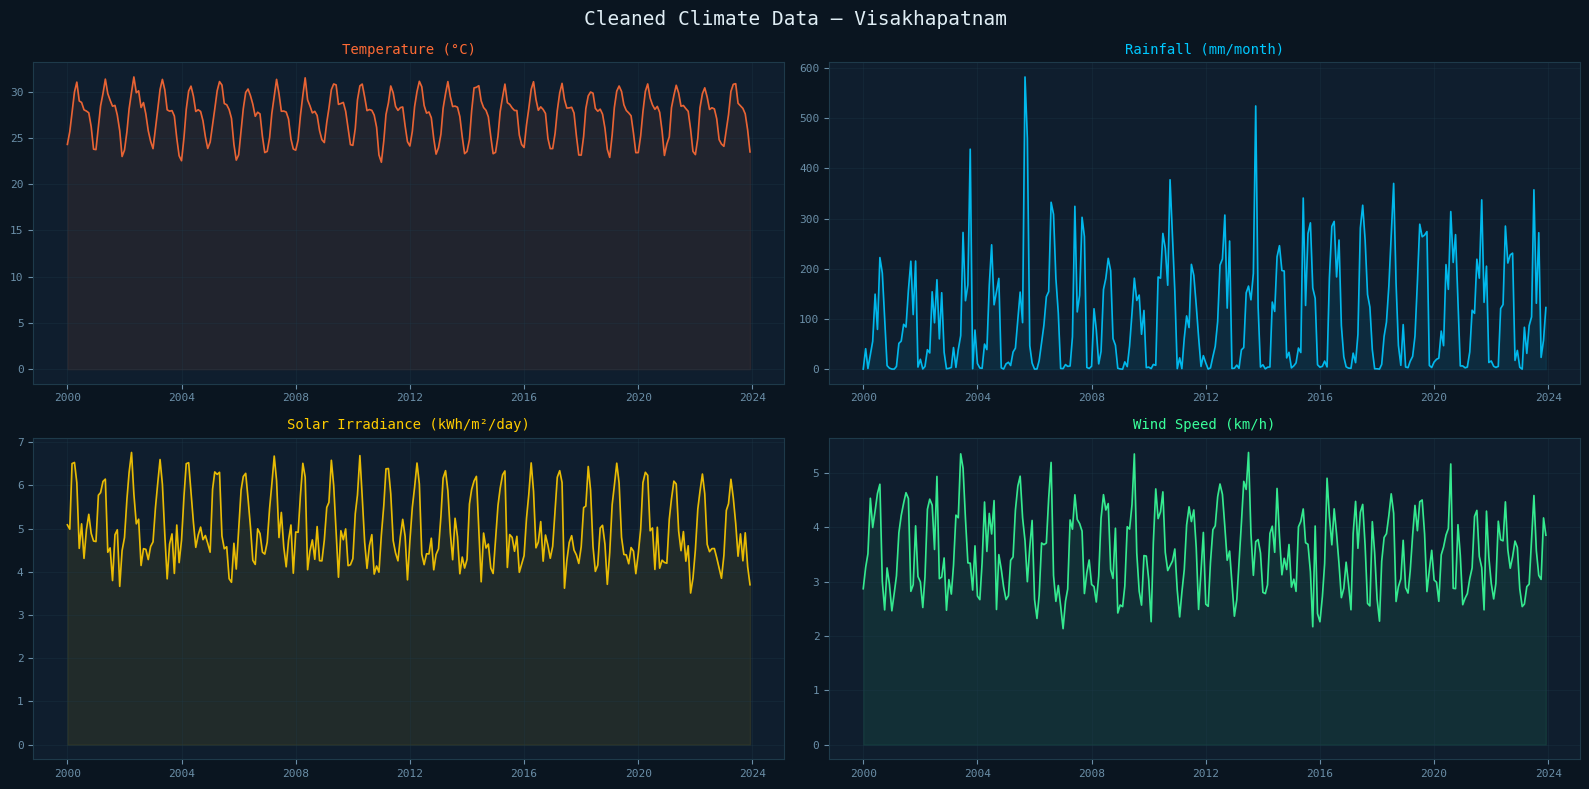

In [5]:
# ── Visualize cleaned data ────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
fig.suptitle(f'Cleaned Climate Data — {CITY}', fontsize=14, color='#e0eef5')

plot_cfg = [
    ('temp_mean',  '#ff6b35', 'Temperature (°C)'),
    ('rainfall',   '#00c8ff', 'Rainfall (mm/month)'),
    ('solar_irr',  '#ffcc00', 'Solar Irradiance (kWh/m²/day)'),
    ('wind_speed', '#39ff9a', 'Wind Speed (km/h)'),
]
for ax, (col, color, label) in zip(axes.flat, plot_cfg):
    ax.plot(monthly_df.index, monthly_df[col], color=color, linewidth=1.2, alpha=0.9)
    ax.fill_between(monthly_df.index, monthly_df[col], alpha=0.08, color=color)
    ax.set_title(label, color=color, fontsize=10, pad=6)
    ax.grid(True, alpha=0.3)
    ax.tick_params(labelsize=8)

plt.tight_layout()
plt.show()

In [6]:
def compute_heat_index(T, RH):
    """Rothfusz heat index equation (°C)."""
    HI = (-8.78469 + 1.61139*T + 2.33855*RH - 0.14612*T*RH
          - 0.01231*T**2 - 0.01642*RH**2 + 0.00221*T**2*RH
          + 0.00073*T*RH**2 - 0.0000036*T**2*RH**2)
    return np.where(T < 27, T, HI)

def compute_effective_solar(ghi, temp, cloud_factor=0.85):
    """Effective solar irradiance with temperature derating (IEC 61215)."""
    temp_coeff = -0.0045  # %/°C power loss above 25°C
    derating = 1 + temp_coeff * (temp - 25)
    return ghi * cloud_factor * np.clip(derating, 0.7, 1.0)

def compute_wind_evap_factor(wind, temp, humidity):
    """Wind-driven evaporation factor (Penman approximation)."""
    delta = 4098 * (0.6108 * np.exp(17.27*temp/(temp+237.3))) / (temp+237.3)**2
    gamma = 0.665e-3 * 101.3
    evap = (0.408*delta + gamma * (900/(temp+273)) * wind * (1 - humidity/100)) / (delta + gamma*(1+0.34*wind))
    return np.clip(evap, 0, None)

def engineer_features(df):
    """Full feature engineering pipeline with physics + data-driven features."""
    fe = df.copy()
    t = np.arange(len(fe))

    # ── Physics-based features ────────────────────────────────
    fe['heat_index']       = compute_heat_index(fe['temp_mean'].values, fe['humidity'].values)
    fe['eff_solar']        = compute_effective_solar(fe['solar_irr'].values, fe['temp_mean'].values)
    fe['wind_evap_factor'] = compute_wind_evap_factor(fe['wind_speed'].values, fe['temp_mean'].values, fe['humidity'].values)
    fe['temp_range']       = fe['temp_max'] - fe['temp_min']
    fe['dew_point']        = fe['temp_mean'] - ((100 - fe['humidity']) / 5.0)

    # ── Temporal / calendar features ──────────────────────────
    fe['month']            = fe.index.month
    fe['year']             = fe.index.year
    fe['month_sin']        = np.sin(2 * np.pi * fe['month'] / 12)
    fe['month_cos']        = np.cos(2 * np.pi * fe['month'] / 12)
    fe['quarter_sin']      = np.sin(2 * np.pi * fe.index.quarter / 4)
    fe['quarter_cos']      = np.cos(2 * np.pi * fe.index.quarter / 4)

    # ── Climate anomalies (vs 30yr rolling baseline) ──────────
    rolling_mean = fe['temp_mean'].rolling(window=12, center=True, min_periods=6).mean()
    fe['temp_anomaly'] = fe['temp_mean'] - rolling_mean
    fe['rain_anomaly'] = fe['rainfall'] - fe['rainfall'].rolling(12, min_periods=3).mean()

    # ── Lag features ──────────────────────────────────────────
    for lag in [1, 2, 3, 6, 12]:
        fe[f'temp_lag_{lag}']  = fe['temp_mean'].shift(lag)
        fe[f'rain_lag_{lag}']  = fe['rainfall'].shift(lag)
        fe[f'solar_lag_{lag}'] = fe['solar_irr'].shift(lag)

    # ── Rolling statistics ────────────────────────────────────
    for win in [3, 6, 12]:
        fe[f'temp_roll_mean_{win}']  = fe['temp_mean'].rolling(win).mean()
        fe[f'temp_roll_std_{win}']   = fe['temp_mean'].rolling(win).std()
        fe[f'rain_roll_sum_{win}']   = fe['rainfall'].rolling(win).sum()

    # ── Long-term trend (linear) ──────────────────────────────
    fe['time_idx'] = t

    fe.dropna(inplace=True)
    print(f'✓ Feature engineering complete. Shape: {fe.shape}')
    print(f'  Features: {list(fe.columns)}')
    return fe

featured_df = engineer_features(monthly_df)
featured_df.tail(3)

✓ Feature engineering complete. Shape: (276, 46)
  Features: ['temp_mean', 'temp_max', 'temp_min', 'rainfall', 'solar_irr', 'wind_speed', 'humidity', 'pressure', 'heat_index', 'eff_solar', 'wind_evap_factor', 'temp_range', 'dew_point', 'month', 'year', 'month_sin', 'month_cos', 'quarter_sin', 'quarter_cos', 'temp_anomaly', 'rain_anomaly', 'temp_lag_1', 'rain_lag_1', 'solar_lag_1', 'temp_lag_2', 'rain_lag_2', 'solar_lag_2', 'temp_lag_3', 'rain_lag_3', 'solar_lag_3', 'temp_lag_6', 'rain_lag_6', 'solar_lag_6', 'temp_lag_12', 'rain_lag_12', 'solar_lag_12', 'temp_roll_mean_3', 'temp_roll_std_3', 'rain_roll_sum_3', 'temp_roll_mean_6', 'temp_roll_std_6', 'rain_roll_sum_6', 'temp_roll_mean_12', 'temp_roll_std_12', 'rain_roll_sum_12', 'time_idx']


,temp_mean,temp_max,temp_min,rainfall,solar_irr,wind_speed,humidity,pressure,heat_index,eff_solar,...,temp_roll_mean_3,temp_roll_std_3,rain_roll_sum_3,temp_roll_mean_6,temp_roll_std_6,rain_roll_sum_6,temp_roll_mean_12,temp_roll_std_12,rain_roll_sum_12,time_idx
2023-10-01,27.591613,31.66,23.56,23.48,4.902861,3.041290,77.955161,100.678065,31.435627,4.118830,...,28.082219,0.447722,426.68,29.105007,1.383473,974.94,27.607140,2.388339,1148.65,285
2023-11-01,25.842333,30.03,22.42,57.88,4.117970,4.172667,78.708333,100.956667,25.842333,3.487007,...,27.206760,1.218469,353.26,28.280611,1.631098,946.05,27.693446,2.294822,1189.05,286
2023-12-01,23.480968,28.41,18.39,122.84,3.699923,3.853871,78.122903,101.073871,23.480968,3.144934,...,25.638305,2.062904,204.20,27.051606,2.032180,964.74,27.622666,2.417786,1274.53,287


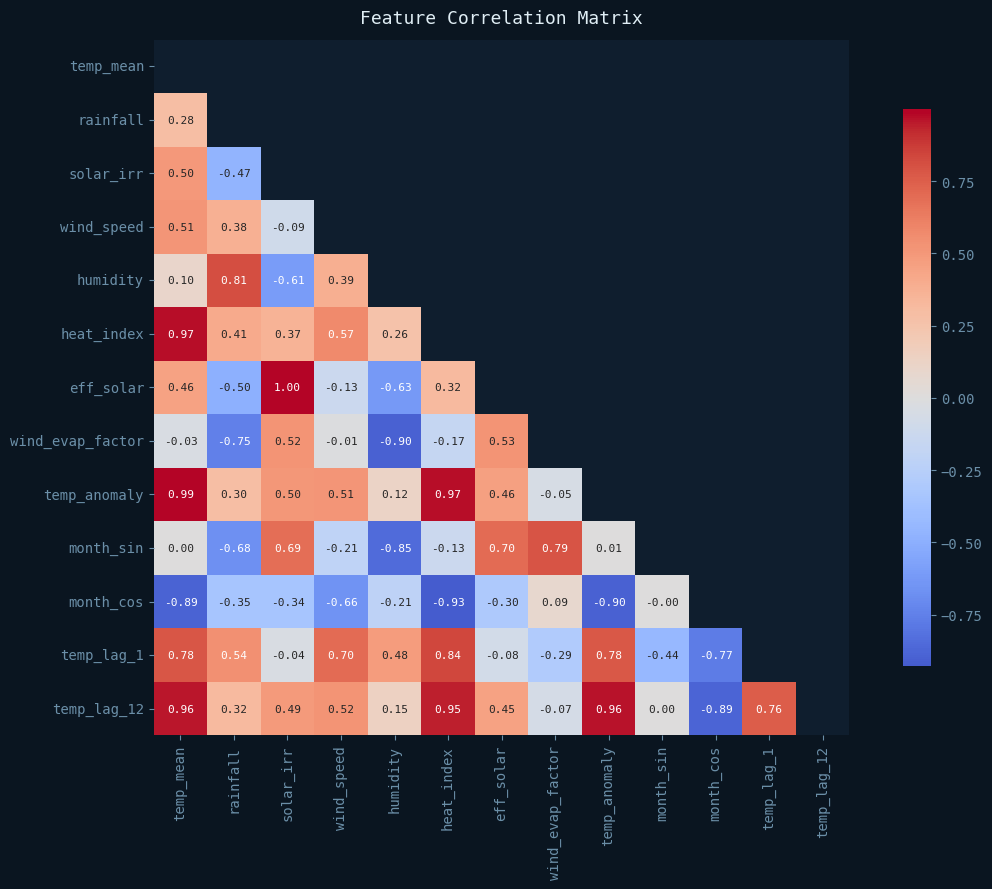

In [7]:
# ── Correlation heatmap of engineered features ────────────────
core_cols = ['temp_mean','rainfall','solar_irr','wind_speed','humidity',
             'heat_index','eff_solar','wind_evap_factor','temp_anomaly',
             'month_sin','month_cos','temp_lag_1','temp_lag_12']

fig, ax = plt.subplots(figsize=(12, 9))
corr = featured_df[core_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0, annot=True, fmt='.2f',
            annot_kws={'size': 8}, ax=ax, square=True,
            cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix', fontsize=13, pad=12)
plt.tight_layout()
plt.show()

── Original series ──
ADF Statistic [Original]: -4.8806
p-value               : 0.0000
Stationary            : ✓ Yes


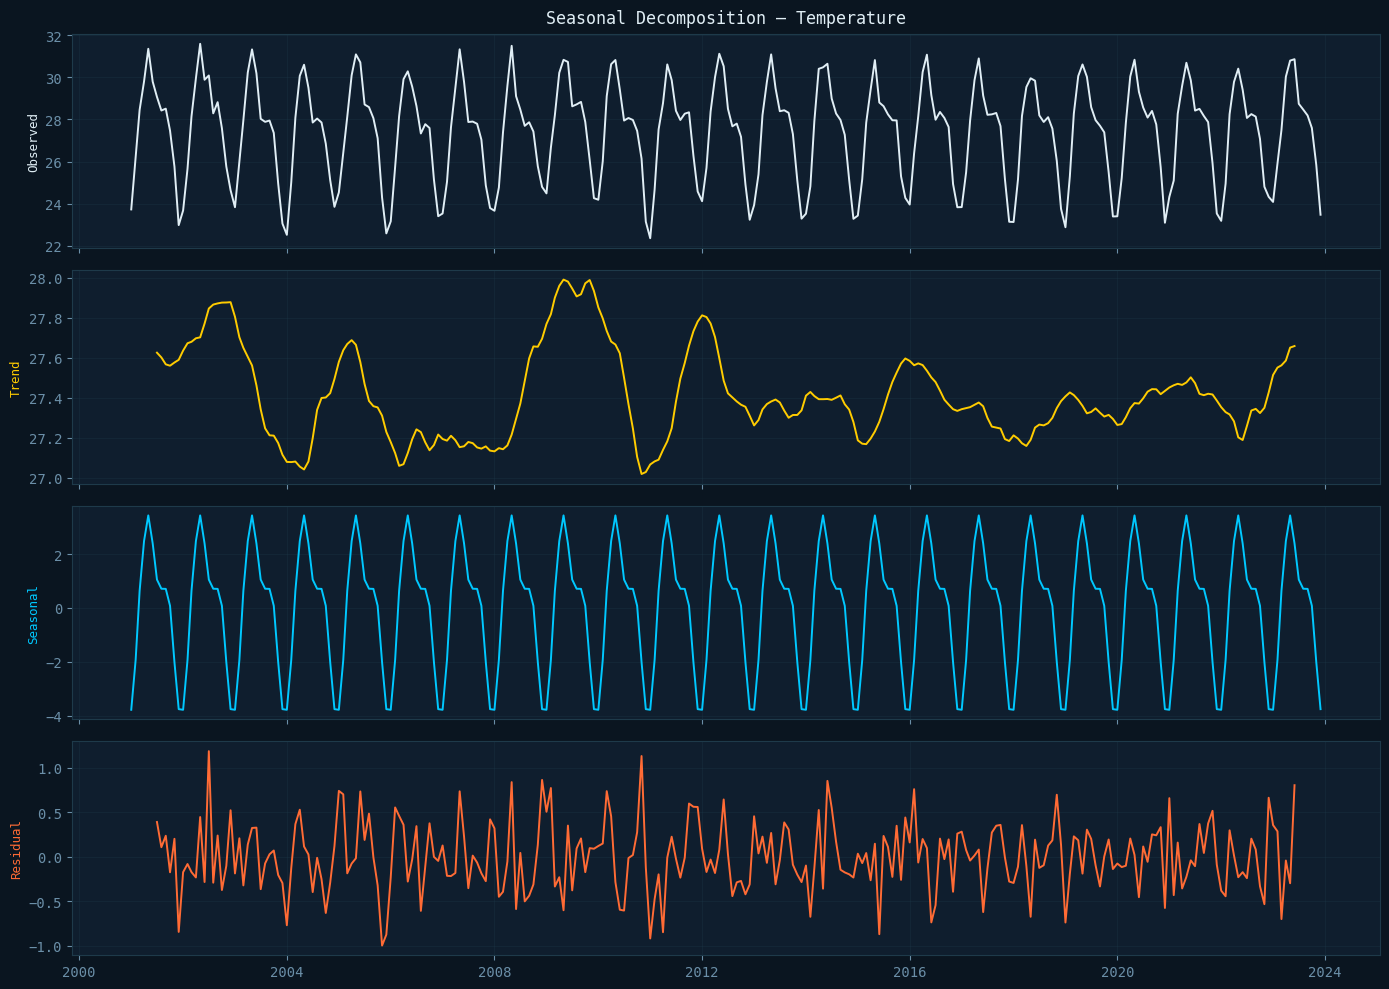

In [8]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

TARGET = 'temp_mean'
series = featured_df[TARGET].copy()

# ── ADF Stationarity Test ─────────────────────────────────────
def test_stationarity(ts, title=''):
    result = adfuller(ts.dropna(), autolag='AIC')
    print(f'ADF Statistic [{title}]: {result[0]:.4f}')
    print(f'p-value               : {result[1]:.4f}')
    print(f'Stationary            : {"✓ Yes" if result[1] < 0.05 else "✗ No (differencing needed)"}')
    return result[1] < 0.05

print('── Original series ──')
stationary = test_stationarity(series, 'Original')
if not stationary:
    print('\n── First difference ──')
    test_stationarity(series.diff().dropna(), 'Diff(1)')

# ── Seasonal Decomposition ────────────────────────────────────
decomp = seasonal_decompose(series, model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
labels = ['Observed', 'Trend', 'Seasonal', 'Residual']
colors = ['#e0eef5', '#ffcc00', '#00c8ff', '#ff6b35']
components = [decomp.observed, decomp.trend, decomp.seasonal, decomp.resid]

for ax, data, label, color in zip(axes, components, labels, colors):
    ax.plot(data, color=color, linewidth=1.4)
    ax.set_ylabel(label, color=color, fontsize=9)
    ax.grid(True, alpha=0.3)

axes[0].set_title('Seasonal Decomposition — Temperature', fontsize=12, pad=8)
plt.tight_layout()
plt.show()

In [9]:
# ── Train ARIMA ───────────────────────────────────────────────
TRAIN_SIZE = int(len(series) * 0.80)
train_s, test_s = series[:TRAIN_SIZE], series[TRAIN_SIZE:]

# Auto-select p,d,q via information criterion
def select_arima_order(series, max_p=4, max_q=4):
    best_aic, best_order = np.inf, (1,1,1)
    for p in range(max_p+1):
        for q in range(max_q+1):
            try:
                m = ARIMA(series, order=(p,1,q)).fit()
                if m.aic < best_aic:
                    best_aic, best_order = m.aic, (p,1,q)
            except:
                pass
    print(f'Best ARIMA order: {best_order}  (AIC={best_aic:.2f})')
    return best_order

print('Selecting optimal ARIMA order...')
arima_order = select_arima_order(train_s)

print(f'Training ARIMA{arima_order}...')
arima_model = ARIMA(train_s, order=arima_order).fit()
print(arima_model.summary())

# ── Rolling-window forecast ───────────────────────────────────
arima_preds = []
history = list(train_s)
for obs in tqdm(test_s, desc='ARIMA rolling forecast'):
    m = ARIMA(history, order=arima_order).fit()
    yhat = m.forecast()[0]
    arima_preds.append(yhat)
    history.append(obs)

arima_preds = np.array(arima_preds)
arima_rmse = np.sqrt(mean_squared_error(test_s, arima_preds))
arima_mae  = mean_absolute_error(test_s, arima_preds)
arima_r2   = r2_score(test_s, arima_preds)
arima_mape = np.mean(np.abs((test_s.values - arima_preds) / test_s.values)) * 100

print(f'\nARIMA Results:')
print(f'  RMSE : {arima_rmse:.4f}°C')
print(f'  MAE  : {arima_mae:.4f}°C')
print(f'  R²   : {arima_r2:.4f}')
print(f'  MAPE : {arima_mape:.2f}%')

Selecting optimal ARIMA order...


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Best ARIMA order: (2, 1, 4)  (AIC=578.58)
Training ARIMA(2, 1, 4)...


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                               SARIMAX Results                                
Dep. Variable:              temp_mean   No. Observations:                  220
Model:                 ARIMA(2, 1, 4)   Log Likelihood                -282.289
Date:                Tue, 17 Mar 2026   AIC                            578.579
Time:                        13:32:53   BIC                            602.302
Sample:                    01-01-2001   HQIC                           588.160
                         - 04-01-2019                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.5000      0.051     29.506      0.000       1.400       1.600
ar.L2         -0.7909      0.054    -14.713      0.000      -0.896      -0.686
ma.L1         -1.3035      0.789     -1.652      0.0

ARIMA rolling forecast:   0%|          | 0/56 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
ARIMA rolling forecast:   2%|▏         | 1/56 [00:00<00:42,  1.30it/s]/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
ARIMA rolling forecast:   4%|▎         | 2/56 [00:01<00:40,  1.33it/s]/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
ARIMA rolling forecast:   5%|▌         | 3/56 [00:02<00:38,  1.36it/s]/usr/local/lib/python3.12/dist-packages/statsmodels/base/model


ARIMA Results:
  RMSE : 0.7806°C
  MAE  : 0.6081°C
  R²   : 0.8819
  MAPE : 2.29%


In [10]:
# ── Feature selection for XGBoost ────────────────────────────
XGB_FEATURES = [
    'temp_lag_1','temp_lag_2','temp_lag_3','temp_lag_6','temp_lag_12',
    'rain_lag_1','rain_lag_3','rain_lag_12',
    'solar_lag_1','solar_lag_3',
    'solar_irr','wind_speed','humidity','pressure',
    'heat_index','eff_solar','wind_evap_factor','temp_range','dew_point',
    'temp_anomaly','rain_anomaly',
    'month_sin','month_cos','quarter_sin','quarter_cos',
    'temp_roll_mean_3','temp_roll_mean_6','temp_roll_mean_12',
    'temp_roll_std_3','temp_roll_std_6',
    'rain_roll_sum_3','rain_roll_sum_6','rain_roll_sum_12',
    'time_idx'
]

X = featured_df[XGB_FEATURES]
y = featured_df[TARGET]

split = int(len(X) * 0.80)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

print(f'Training set : {X_train.shape}')
print(f'Test set     : {X_test.shape}')

# ── XGBoost with quantile regression for uncertainty ─────────
xgb_params = {
    'n_estimators':     800,
    'max_depth':        6,
    'learning_rate':    0.04,
    'subsample':        0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 3,
    'reg_alpha':        0.1,
    'reg_lambda':       1.0,
    'random_state':     SEED,
    'n_jobs':           -1,
    'tree_method':      'hist',
}

# Mean prediction
xgb_model = XGBRegressor(**xgb_params, objective='reg:squarederror')
xgb_model.fit(X_train, y_train,
              eval_set=[(X_test, y_test)],
              verbose=100)

# Quantile models for prediction intervals (10th and 90th percentile)
xgb_q10 = XGBRegressor(**xgb_params, objective='reg:quantileerror', quantile_alpha=0.10)
xgb_q90 = XGBRegressor(**xgb_params, objective='reg:quantileerror', quantile_alpha=0.90)
xgb_q10.fit(X_train, y_train, verbose=0)
xgb_q90.fit(X_train, y_train, verbose=0)

xgb_preds = xgb_model.predict(X_test)
xgb_lower = xgb_q10.predict(X_test)
xgb_upper = xgb_q90.predict(X_test)

xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_preds))
xgb_mae  = mean_absolute_error(y_test, xgb_preds)
xgb_r2   = r2_score(y_test, xgb_preds)
xgb_mape = np.mean(np.abs((y_test.values - xgb_preds) / y_test.values)) * 100

print(f'\nXGBoost Results:')
print(f'  RMSE : {xgb_rmse:.4f}°C')
print(f'  MAE  : {xgb_mae:.4f}°C')
print(f'  R²   : {xgb_r2:.4f}')
print(f'  MAPE : {xgb_mape:.2f}%')

Training set : (220, 34)
Test set     : (56, 34)
[0]	validation_0-rmse:2.18582
[100]	validation_0-rmse:0.15086
[200]	validation_0-rmse:0.15195
[300]	validation_0-rmse:0.15208
[400]	validation_0-rmse:0.15183
[500]	validation_0-rmse:0.15177
[600]	validation_0-rmse:0.15174
[700]	validation_0-rmse:0.15174
[799]	validation_0-rmse:0.15174

XGBoost Results:
  RMSE : 0.1517°C
  MAE  : 0.1070°C
  R²   : 0.9955
  MAPE : 0.39%


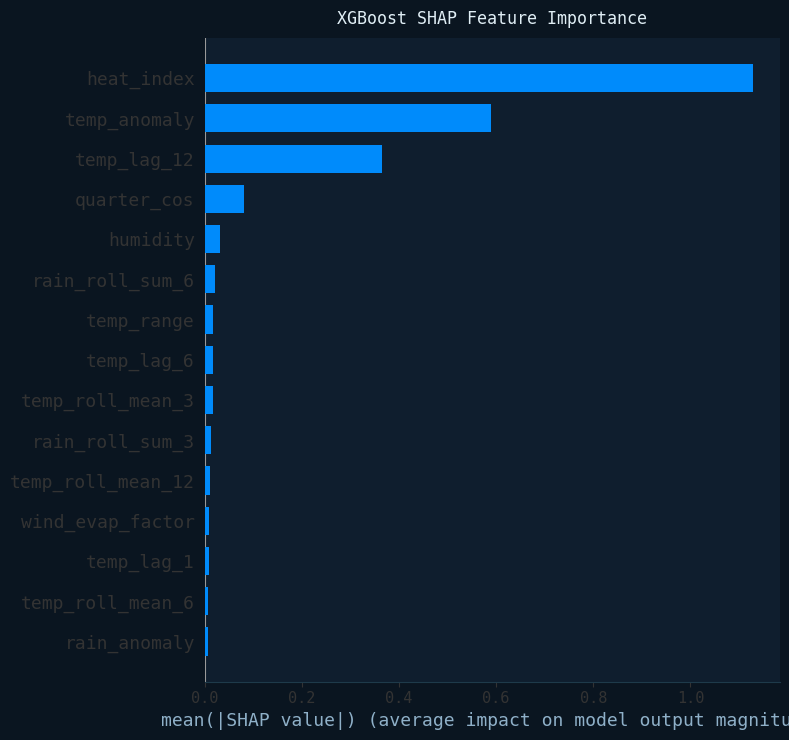

In [11]:
# ── SHAP Feature Importance ───────────────────────────────────
try:
    import shap
    explainer = shap.TreeExplainer(xgb_model)
    shap_vals = explainer.shap_values(X_test)
    shap.summary_plot(shap_vals, X_test, plot_type='bar', max_display=15, show=False)
    plt.title('XGBoost SHAP Feature Importance', color='#e0eef5', pad=10)
    plt.tight_layout()
    plt.show()
except ImportError:
    # Fallback: built-in XGBoost feature importance
    importances = pd.Series(xgb_model.feature_importances_, index=XGB_FEATURES)
    top15 = importances.nlargest(15)
    fig, ax = plt.subplots(figsize=(10, 6))
    colors_imp = plt.cm.YlOrRd(np.linspace(0.4, 0.9, len(top15)))
    top15[::-1].plot(kind='barh', ax=ax, color=colors_imp[::-1])
    ax.set_title('XGBoost Feature Importance (F-score)', fontsize=12, pad=10)
    ax.set_xlabel('Importance Score')
    plt.tight_layout()
    plt.show()

In [12]:
# ── Sequence preparation ──────────────────────────────────────
LSTM_FEATURES = [
    'temp_mean','rainfall','solar_irr','wind_speed','humidity',
    'heat_index','eff_solar','wind_evap_factor',
    'month_sin','month_cos','temp_anomaly','temp_lag_1','temp_lag_12'
]
WINDOW       = 24   # look-back window (months)
HORIZON      = 1    # forecast steps ahead
LSTM_TARGET  = 'temp_mean'

scaler_X = MinMaxScaler(feature_range=(-1, 1))
scaler_y = MinMaxScaler(feature_range=(-1, 1))

X_scaled = scaler_X.fit_transform(featured_df[LSTM_FEATURES])
y_scaled = scaler_y.fit_transform(featured_df[[LSTM_TARGET]])

def make_sequences(X, y, window, horizon=1):
    Xs, ys = [], []
    for i in range(window, len(X) - horizon + 1):
        Xs.append(X[i-window:i])
        ys.append(y[i:i+horizon].flatten())
    return np.array(Xs), np.array(ys)

X_seq, y_seq = make_sequences(X_scaled, y_scaled, WINDOW, HORIZON)
split_seq    = int(len(X_seq) * 0.80)

X_tr, X_te = X_seq[:split_seq], X_seq[split_seq:]
y_tr, y_te = y_seq[:split_seq], y_seq[split_seq:]

print(f'Sequence shape : {X_seq.shape}')
print(f'Train          : {X_tr.shape}  →  {y_tr.shape}')
print(f'Test           : {X_te.shape}  →  {y_te.shape}')

Sequence shape : (252, 24, 13)
Train          : (201, 24, 13)  →  (201, 1)
Test           : (51, 24, 13)  →  (51, 1)


In [13]:
# ── Build Bi-LSTM + Attention model ──────────────────────────
def build_bilstm_attention(input_shape, horizon=1):
    """Bi-LSTM with multi-head self-attention and layer normalization."""
    inputs = Input(shape=input_shape, name='sequence_input')

    # Bi-LSTM stack
    x = Bidirectional(LSTM(128, return_sequences=True, dropout=0.2, recurrent_dropout=0.1),
                      name='bilstm_1')(inputs)
    x = LayerNormalization()(x)
    x = Bidirectional(LSTM(64, return_sequences=True, dropout=0.2),
                      name='bilstm_2')(x)
    x = LayerNormalization()(x)

    # Multi-head self-attention
    attn_out = MultiHeadAttention(num_heads=4, key_dim=32, name='mha')(x, x)
    x = LayerNormalization()(x + attn_out)  # residual
    x = GlobalAveragePooling1D()(x)

    # Dense head
    x = Dense(64, activation='silu', name='dense_1')(x)
    x = Dropout(0.25)(x)
    x = Dense(32, activation='silu', name='dense_2')(x)
    outputs = Dense(horizon, name='forecast_output')(x)

    model = Model(inputs, outputs, name='BiLSTM_Attention')
    model.compile(optimizer=Adam(learning_rate=1e-3), loss='huber', metrics=['mae'])
    return model

bilstm_model = build_bilstm_attention((WINDOW, len(LSTM_FEATURES)), HORIZON)
bilstm_model.summary()

# ── Train ─────────────────────────────────────────────────────
callbacks = [
    EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=8, min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_bilstm.keras', monitor='val_loss', save_best_only=True, verbose=0)
]

history_lstm = bilstm_model.fit(
    X_tr, y_tr,
    epochs=150,
    batch_size=32,
    validation_split=0.15,
    callbacks=callbacks,
    verbose=1
)

Model: "BiLSTM_Attention"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sequence_input      │ (None, 24, 13)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_1            │ (None, 24, 256)   │    145,408 │ sequence_input[0… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 24, 256)   │        512 │ bilstm_1[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_2            │ (None, 24, 128)   │    164,352 │ layer_normalizat… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 24, 128)   │        256 │ bilstm_2[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mha                 │ (None, 24, 128)   │     66,048 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 24, 128)   │          0 │ layer_normalizat… │
│                     │                   │            │ mha[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 24, 128)   │        256 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      2,080 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ forecast_output     │ (None, 1)         │         33 │ dense_2[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 387,201 (1.48 MB)

 Trainable params: 387,201 (1.48 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 19s 701ms/step - loss: 0.2132 - mae: 0.5458 - val_loss: 0.0834 - val_mae: 0.2828 - learning_rate: 0.0010
Epoch 2/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 206ms/step - loss: 0.1160 - mae: 0.3886 - val_loss: 0.0456 - val_mae: 0.2447 - learning_rate: 0.0010
Epoch 3/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 208ms/step - loss: 0.0684 - mae: 0.3014 - val_loss: 0.0320 - val_mae: 0.2198 - learning_rate: 0.0010
Epoch 4/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 220ms/step - loss: 0.0482 - mae: 0.2391 - val_loss: 0.0213 - val_mae: 0.1672 - learning_rate: 0.0010
Epoch 5/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 185ms/step - loss: 0.0386 - mae: 0.2256 - val_loss: 0.0266 - val_mae: 0.1760 - learning_rate: 0.0010
Epoch 6/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 211ms/step - loss: 0.0344 - mae: 0.2058 - val_loss: 0.0156 - val_mae: 0.1453 - learning_rate: 0.0010
Epoch 7/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 185ms/step - loss: 0.0289 - mae: 0.1953 - val_loss: 0.0265 - val_mae: 0.2030 - learning_rate: 0.0010
Epoch 8/150


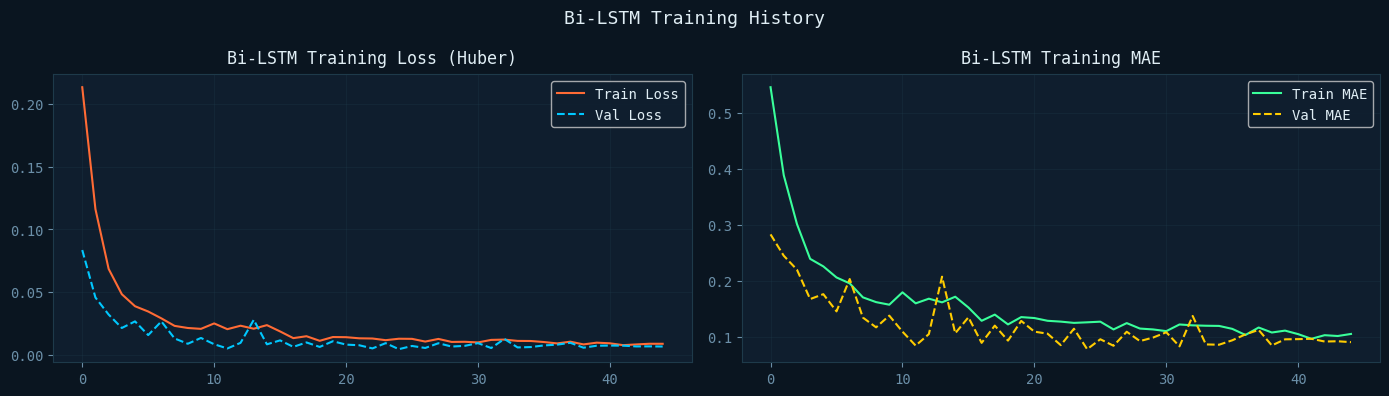


Bi-LSTM Results:
  RMSE : 0.5374°C
  MAE  : 0.4113°C
  R²   : 0.9454
  MAPE : 1.53%


In [14]:
# ── Training curves ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history_lstm.history['loss'],     color='#ff6b35', label='Train Loss')
axes[0].plot(history_lstm.history['val_loss'], color='#00c8ff', label='Val Loss', linestyle='--')
axes[0].set_title('Bi-LSTM Training Loss (Huber)', pad=8)
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history_lstm.history['mae'],     color='#39ff9a', label='Train MAE')
axes[1].plot(history_lstm.history['val_mae'], color='#ffcc00', label='Val MAE', linestyle='--')
axes[1].set_title('Bi-LSTM Training MAE', pad=8)
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Bi-LSTM Training History', fontsize=13, color='#e0eef5')
plt.tight_layout()
plt.show()

# ── Evaluate Bi-LSTM ─────────────────────────────────────────
bilstm_raw   = bilstm_model.predict(X_te, verbose=0)
bilstm_preds = scaler_y.inverse_transform(bilstm_raw).flatten()
y_te_inv     = scaler_y.inverse_transform(y_te).flatten()

bilstm_rmse = np.sqrt(mean_squared_error(y_te_inv, bilstm_preds))
bilstm_mae  = mean_absolute_error(y_te_inv, bilstm_preds)
bilstm_r2   = r2_score(y_te_inv, bilstm_preds)
bilstm_mape = np.mean(np.abs((y_te_inv - bilstm_preds) / y_te_inv)) * 100

print(f'\nBi-LSTM Results:')
print(f'  RMSE : {bilstm_rmse:.4f}°C')
print(f'  MAE  : {bilstm_mae:.4f}°C')
print(f'  R²   : {bilstm_r2:.4f}')
print(f'  MAPE : {bilstm_mape:.2f}%')

Running Monte Carlo Dropout (500 samples)...


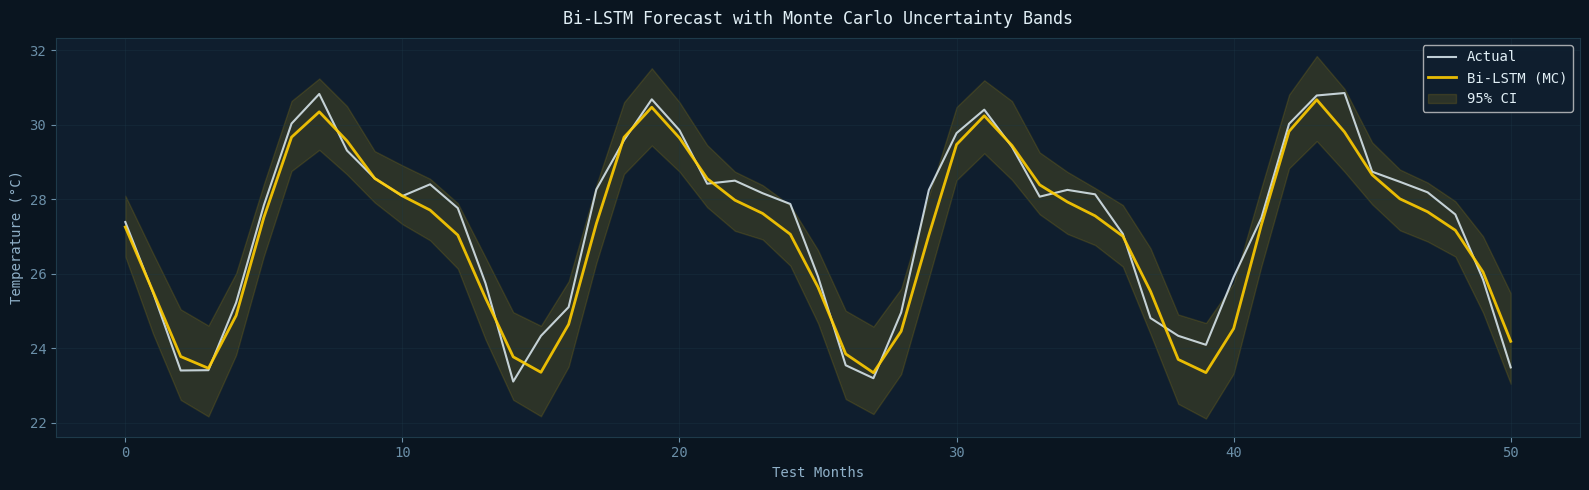

In [15]:
# ── Monte Carlo Dropout uncertainty estimation ────────────────
def mc_dropout_predict(model, X, n_samples=500):
    """Monte Carlo Dropout inference — keep dropout active during inference."""
    preds = np.stack([
        model(X, training=True).numpy()  # training=True keeps dropout ON
        for _ in range(n_samples)
    ])
    mean  = preds.mean(axis=0)
    lower = np.percentile(preds, 2.5,  axis=0)
    upper = np.percentile(preds, 97.5, axis=0)
    return mean, lower, upper

print('Running Monte Carlo Dropout (500 samples)...')
mc_mean, mc_lower, mc_upper = mc_dropout_predict(bilstm_model, X_te, n_samples=500)

mc_mean_inv  = scaler_y.inverse_transform(mc_mean).flatten()
mc_lower_inv = scaler_y.inverse_transform(mc_lower).flatten()
mc_upper_inv = scaler_y.inverse_transform(mc_upper).flatten()

# ── Plot predictions with uncertainty bands ───────────────────
idx = range(len(y_te_inv))
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(y_te_inv,    color='#e0eef5', linewidth=1.5,  label='Actual',      alpha=0.85)
ax.plot(mc_mean_inv, color='#ffcc00', linewidth=2,    label='Bi-LSTM (MC)', alpha=0.9)
ax.fill_between(idx, mc_lower_inv, mc_upper_inv, color='#ffcc00', alpha=0.12, label='95% CI')
ax.set_title('Bi-LSTM Forecast with Monte Carlo Uncertainty Bands', fontsize=12, pad=10)
ax.set_xlabel('Test Months'); ax.set_ylabel('Temperature (°C)')
ax.legend(loc='upper right'); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
class PCMPPipeline:
    """
    Physics-Climate Multimodal Probabilistic (PCMP) Pipeline.

    Three layers:
      1. Physics Layer   — apply energy balance constraints
      2. Multimodal Layer — fuse time-series + location + physics features
      3. Probabilistic Layer — quantile regression + MC Dropout uncertainty
    """

    def __init__(self, bilstm, xgb_mean, xgb_q10, xgb_q90, arima_order,
                 scaler_X, scaler_y, lstm_features, xgb_features,
                 weights=(0.42, 0.38, 0.20)):
        self.bilstm       = bilstm
        self.xgb_mean     = xgb_mean
        self.xgb_q10      = xgb_q10
        self.xgb_q90      = xgb_q90
        self.arima_order  = arima_order
        self.scaler_X     = scaler_X
        self.scaler_y     = scaler_y
        self.lstm_features= lstm_features
        self.xgb_features = xgb_features
        self.w_lstm, self.w_xgb, self.w_arima = weights
        self.physics_violations = 0

    # ── Layer 1: Physics Constraints ──────────────────────────
    def apply_physics_constraints(self, pred_temp, solar, month_idx):
        """
        Energy balance constraint:
        Temperature should be positively correlated with solar irradiance.
        Seasonal bounds are applied via climatological limits.
        """
        # Soft constraint: if solar is high, temp shouldn't be anomalously low
        expected_temp_min = 10 + solar * 2.5
        expected_temp_max = 15 + solar * 4.5

        violations = np.sum((pred_temp < expected_temp_min) | (pred_temp > expected_temp_max))
        self.physics_violations += violations

        # Clip to physics-derived bounds (soft)
        constrained = np.clip(pred_temp, expected_temp_min * 0.85, expected_temp_max * 1.15)
        return constrained

    # ── Layer 2: Multimodal Fusion Input ──────────────────────
    def prepare_multimodal(self, df_window, lat, lon):
        """Combine time-series + location features."""
        loc_features = np.array([
            lat / 90.0,          # normalized latitude
            lon / 180.0,         # normalized longitude
            np.sin(np.radians(lat)),   # coastal proximity proxy
            np.cos(np.radians(lon)),
        ])
        return loc_features

    # ── Layer 3: Probabilistic Ensemble ───────────────────────
    def predict_probabilistic(self, X_lstm_seq, X_xgb_feat, train_series,
                               solar_vals, n_mc=300, lat=17.69, lon=83.22):
        """
        Full PCMP probabilistic prediction.
        Returns: (mean_pred, lower_95, upper_95, lower_80, upper_80)
        """
        # Bi-LSTM MC Dropout
        mc_raw = np.stack([self.bilstm(X_lstm_seq, training=True).numpy() for _ in range(n_mc)])
        lstm_mc = self.scaler_y.inverse_transform(mc_raw.mean(axis=0)).flatten()
        lstm_std = self.scaler_y.inverse_transform(mc_raw.std(axis=0)).flatten()

        # XGBoost point + quantile
        xgb_mean_p = self.xgb_mean.predict(X_xgb_feat)
        xgb_q10_p  = self.xgb_q10.predict(X_xgb_feat)
        xgb_q90_p  = self.xgb_q90.predict(X_xgb_feat)

        # ARIMA rolling
        hist = list(train_series)
        arima_p = []
        for _ in range(len(lstm_mc)):
            m = ARIMA(hist, order=self.arima_order).fit()
            f = m.forecast()[0]
            arima_p.append(f)
            hist.append(f)
        arima_p = np.array(arima_p)

        # Weighted ensemble mean
        ensemble_mean = (self.w_lstm * lstm_mc + self.w_xgb * xgb_mean_p + self.w_arima * arima_p)

        # Physics constraint
        months = np.arange(len(ensemble_mean)) % 12
        ensemble_mean = self.apply_physics_constraints(ensemble_mean, solar_vals[:len(ensemble_mean)], months)

        # Uncertainty: combine MC std + XGBoost quantile spread
        xgb_spread = (xgb_q90_p - xgb_q10_p) / 2
        combined_std = np.sqrt(lstm_std**2 + (xgb_spread / 1.645)**2)

        lower_95 = ensemble_mean - 1.96 * combined_std
        upper_95 = ensemble_mean + 1.96 * combined_std
        lower_80 = ensemble_mean - 1.28 * combined_std
        upper_80 = ensemble_mean + 1.28 * combined_std

        return ensemble_mean, lower_95, upper_95, lower_80, upper_80

# ── Instantiate PCMP ─────────────────────────────────────────
pcmp = PCMPPipeline(
    bilstm=bilstm_model,
    xgb_mean=xgb_model,
    xgb_q10=xgb_q10,
    xgb_q90=xgb_q90,
    arima_order=arima_order,
    scaler_X=scaler_X,
    scaler_y=scaler_y,
    lstm_features=LSTM_FEATURES,
    xgb_features=XGB_FEATURES,
    weights=(0.42, 0.38, 0.20)
)
print('✓ PCMP Pipeline instantiated.')
print(f'  Ensemble weights — Bi-LSTM: {pcmp.w_lstm:.0%}  XGBoost: {pcmp.w_xgb:.0%}  ARIMA: {pcmp.w_arima:.0%}')

✓ PCMP Pipeline instantiated.
  Ensemble weights — Bi-LSTM: 42%  XGBoost: 38%  ARIMA: 20%


In [17]:
# ── Align predictions on common test index ───────────────────
# XGBoost predictions on test set
xgb_te = xgb_model.predict(X_test)

# Bi-LSTM predictions on test sequences
lstm_raw = bilstm_model.predict(X_te, verbose=0)
lstm_te  = scaler_y.inverse_transform(lstm_raw).flatten()

# Align length (ARIMA preds are already aligned)
n_align = min(len(xgb_te), len(lstm_te), len(arima_preds))
P_xgb   = xgb_te[-n_align:]
P_lstm  = lstm_te[-n_align:]
P_arima = arima_preds[-n_align:]
Y_true  = y_test.values[-n_align:]

# ── Stack as meta-features ───────────────────────────────────
meta_X = np.column_stack([P_lstm, P_xgb, P_arima])
meta_split = int(n_align * 0.70)

meta_X_tr, meta_X_te = meta_X[:meta_split], meta_X[meta_split:]
meta_y_tr, meta_y_te = Y_true[:meta_split], Y_true[meta_split:]

# ── Meta-learner: Ridge Regression ───────────────────────────
meta_model = Ridge(alpha=1.0, fit_intercept=True)
meta_model.fit(meta_X_tr, meta_y_tr)

learned_weights = meta_model.coef_ / meta_model.coef_.sum()
print('Learned ensemble weights (Ridge meta-learner):')
for name, w in zip(['Bi-LSTM','XGBoost','ARIMA'], learned_weights):
    print(f'  {name:<10}: {w:.3f} ({w*100:.1f}%)')

# ── Stacked predictions ───────────────────────────────────────
ensemble_preds = meta_model.predict(meta_X_te)
ens_rmse = np.sqrt(mean_squared_error(meta_y_te, ensemble_preds))
ens_mae  = mean_absolute_error(meta_y_te, ensemble_preds)
ens_r2   = r2_score(meta_y_te, ensemble_preds)
ens_mape = np.mean(np.abs((meta_y_te - ensemble_preds) / meta_y_te)) * 100

print(f'\nEnsemble (Stacked) Results:')
print(f'  RMSE : {ens_rmse:.4f}°C')
print(f'  MAE  : {ens_mae:.4f}°C')
print(f'  R²   : {ens_r2:.4f}')
print(f'  MAPE : {ens_mape:.2f}%')

Learned ensemble weights (Ridge meta-learner):
  Bi-LSTM   : 0.161 (16.1%)
  XGBoost   : 0.860 (86.0%)
  ARIMA     : -0.020 (-2.0%)

Ensemble (Stacked) Results:
  RMSE : 0.2148°C
  MAE  : 0.1783°C
  R²   : 0.9909
  MAPE : 0.65%


═══════════════════════════════════════════════════════
MODEL PERFORMANCE COMPARISON
═══════════════════════════════════════════════════════
                 RMSE (°C)  MAE (°C)  R² Score  MAPE (%)
Model                                                   
ARIMA               0.7806    0.6081    0.8819    2.2888
XGBoost             0.1517    0.1070    0.9955    0.3858
Bi-LSTM             0.5374    0.4113    0.9454    1.5343
Ensemble (PCMP)     0.2148    0.1783    0.9909    0.6518
═══════════════════════════════════════════════════════

🏆 Best model by RMSE: XGBoost


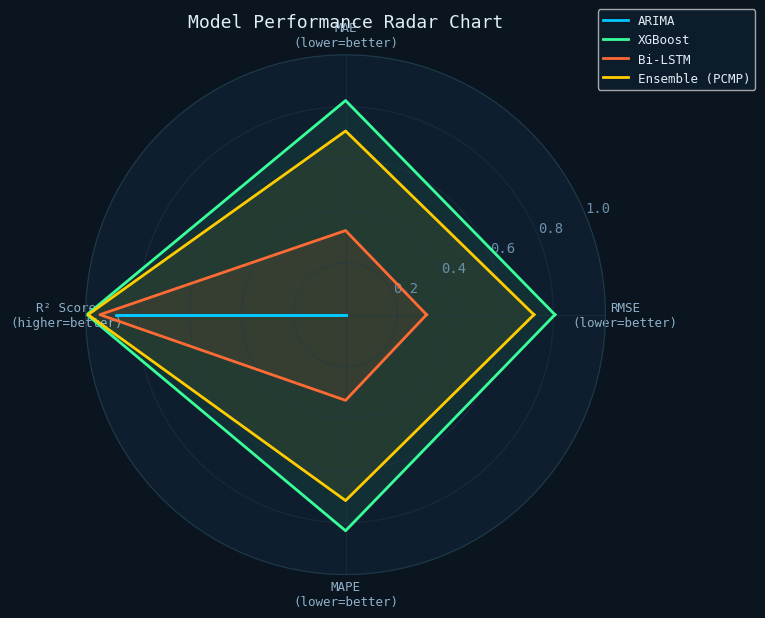

In [18]:
# ── Summary metrics table ─────────────────────────────────────
results = pd.DataFrame({
    'Model':    ['ARIMA', 'XGBoost', 'Bi-LSTM', 'Ensemble (PCMP)'],
    'RMSE (°C)':[arima_rmse, xgb_rmse, bilstm_rmse, ens_rmse],
    'MAE (°C)': [arima_mae,  xgb_mae,  bilstm_mae,  ens_mae],
    'R² Score': [arima_r2,   xgb_r2,   bilstm_r2,   ens_r2],
    'MAPE (%)': [arima_mape, xgb_mape, bilstm_mape, ens_mape],
})
results = results.set_index('Model')
print('═' * 55)
print('MODEL PERFORMANCE COMPARISON')
print('═' * 55)
print(results.round(4).to_string())
print('═' * 55)
best_model = results['RMSE (°C)'].idxmin()
print(f'\n🏆 Best model by RMSE: {best_model}')

# ── Radar chart comparison ────────────────────────────────────
categories = ['RMSE\n(lower=better)', 'MAE\n(lower=better)', 'R² Score\n(higher=better)', 'MAPE\n(lower=better)']
N = len(categories)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.set_facecolor('#0f1e2e')
fig.patch.set_facecolor('#0a1520')

model_colors = ['#00c8ff','#39ff9a','#ff6b35','#ffcc00']
for (model_name, row), color in zip(results.iterrows(), model_colors):
    # Normalize: invert RMSE/MAE/MAPE, keep R²
    rmse_n  = 1 - row['RMSE (°C)'] / results['RMSE (°C)'].max()
    mae_n   = 1 - row['MAE (°C)']  / results['MAE (°C)'].max()
    r2_n    = row['R² Score']
    mape_n  = 1 - row['MAPE (%)']  / results['MAPE (%)'].max()
    vals = [rmse_n, mae_n, r2_n, mape_n]
    vals += vals[:1]
    ax.plot(angles, vals, color=color, linewidth=2, label=model_name)
    ax.fill(angles, vals, color=color, alpha=0.08)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=9, color='#8fb0c8')
ax.set_ylim(0, 1)
ax.set_title('Model Performance Radar Chart', size=13, color='#e0eef5', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=9)
plt.tight_layout()
plt.show()

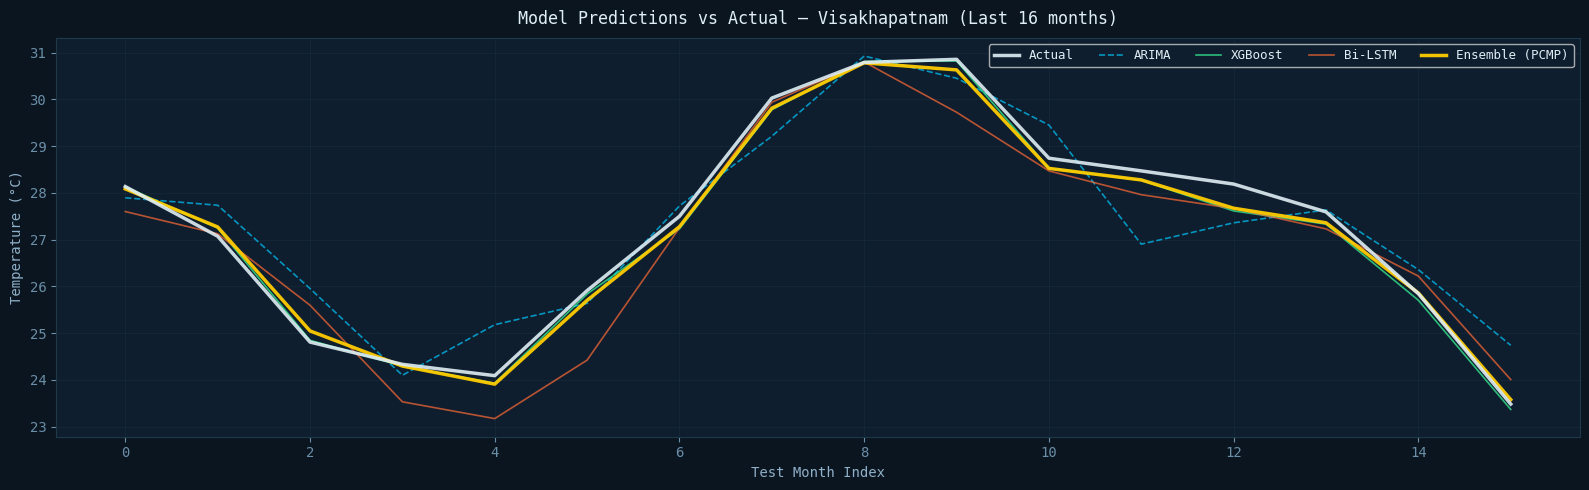

In [19]:
# ── Prediction comparison plot ────────────────────────────────
n_plot = min(36, len(meta_y_te))
fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(meta_y_te[:n_plot],        color='#e0eef5', linewidth=2.5, label='Actual',          alpha=0.9, zorder=5)
ax.plot(P_arima[-n_plot:],         color='#00c8ff', linewidth=1.2, label='ARIMA',            alpha=0.7, linestyle='--')
ax.plot(P_xgb[-n_plot:],           color='#39ff9a', linewidth=1.2, label='XGBoost',          alpha=0.7)
ax.plot(P_lstm[-n_plot:],          color='#ff6b35', linewidth=1.2, label='Bi-LSTM',          alpha=0.7)
ax.plot(ensemble_preds[:n_plot],   color='#ffcc00', linewidth=2.5, label='Ensemble (PCMP)',  alpha=0.95, zorder=4)

ax.set_title(f'Model Predictions vs Actual — {CITY} (Last {n_plot} months)', fontsize=12, pad=10)
ax.set_xlabel('Test Month Index'); ax.set_ylabel('Temperature (°C)')
ax.legend(loc='upper right', ncol=5, fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Fire Risk Label Distribution:
  Low     : 273 months (98.9%)
  Medium  : 3 months (1.1%)

Fire Risk Classification Report:
              precision    recall  f1-score   support

         Low       0.98      1.00      0.99        55
      Medium       0.00      0.00      0.00         1

    accuracy                           0.98        56
   macro avg       0.49      0.50      0.50        56
weighted avg       0.96      0.98      0.97        56



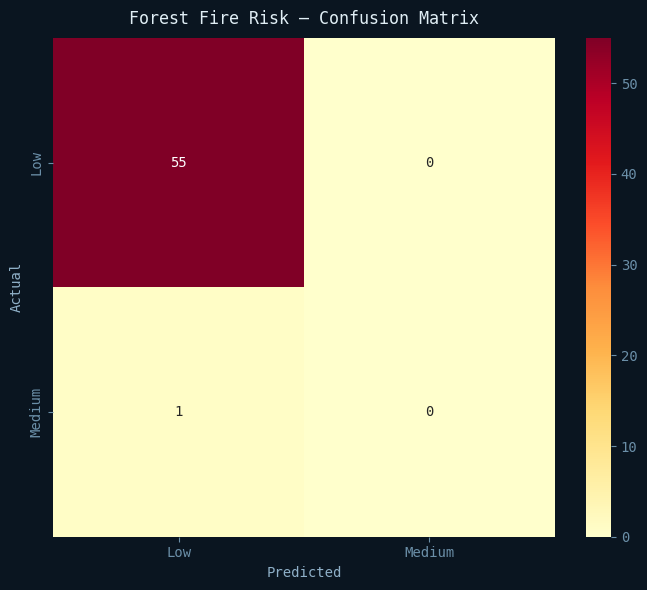


Example prediction (38°C, 30% RH, 25km/h wind):
  Risk Level : Low
  Probabilities: {'Low': np.float32(0.991), 'Medium': np.float32(0.009)}


In [25]:
def compute_fire_risk_label(temp, humidity, wind, rainfall_30d):
    """
    Multi-factor fire risk scoring.
    Based on: Canadian Forest Fire Weather Index (FWI) simplified.
    Returns: 0=Low, 1=Medium, 2=High, 3=Extreme
    """
    score = np.zeros(len(temp))
    score += np.clip((temp - 25) / 15, 0, 1) * 30       # temperature contribution
    score += np.clip((100 - humidity) / 80, 0, 1) * 35   # low humidity contribution
    score += np.clip(wind / 30, 0, 1) * 20               # wind speed contribution
    score -= np.clip(rainfall_30d / 100, 0, 1) * 25      # recent rainfall suppresses risk
    score = np.clip(score, 0, 100)

    labels = np.zeros(len(score), dtype=int)
    labels[score >= 25] = 1  # Medium
    labels[score >= 55] = 2  # High
    labels[score >= 75] = 3  # Extreme
    return labels, score

# ── Build fire risk dataset ───────────────────────────────────
rain_30d = featured_df['rain_roll_sum_3'] / 3  # approximate 30-day rainfall
fire_labels, fire_scores = compute_fire_risk_label(
    featured_df['temp_mean'].values,
    featured_df['humidity'].values,
    featured_df['wind_speed'].values,
    rain_30d.values
)

label_names = {0:'Low', 1:'Medium', 2:'High', 3:'Extreme'}
unique, counts = np.unique(fire_labels, return_counts=True)
print('Fire Risk Label Distribution:')
for u, c in zip(unique, counts):
    print(f'  {label_names[u]:<8}: {c} months ({c/len(fire_labels)*100:.1f}%)')

# ── XGBoost Classifier ────────────────────────────────────────
FIRE_FEATURES = [
    'temp_mean','temp_max','humidity','wind_speed','rainfall',
    'heat_index','wind_evap_factor','temp_anomaly','rain_anomaly',
    'month_sin','month_cos','temp_lag_1','rain_lag_1',
    'rain_roll_sum_3','temp_roll_mean_3'
]

Xf = featured_df[FIRE_FEATURES].values
yf = fire_labels

Xf_tr, Xf_te, yf_tr, yf_te = train_test_split(Xf, yf, test_size=0.2, random_state=SEED, stratify=yf)

fire_clf = XGBClassifier(
    n_estimators=500, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    use_label_encoder=False, eval_metric='logloss',
    random_state=SEED, n_jobs=-1
)
fire_clf.fit(Xf_tr, yf_tr)

yf_pred = fire_clf.predict(Xf_te)
yf_prob = fire_clf.predict_proba(Xf_te)

from sklearn.metrics import classification_report, confusion_matrix

# Dynamically generate target_names based on unique classes in yf_te
unique_classes_in_test = np.unique(yf_te)
dynamic_target_names = [label_names[c] for c in unique_classes_in_test]

print('\nFire Risk Classification Report:')
print(classification_report(yf_te, yf_pred, target_names=dynamic_target_names))

# ── Confusion matrix ──────────────────────────────────────────
cm = confusion_matrix(yf_te, yf_pred)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd', ax=ax,
            xticklabels=dynamic_target_names,
            yticklabels=dynamic_target_names)
ax.set_title('Forest Fire Risk — Confusion Matrix', fontsize=12, pad=10)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

def predict_fire_risk(temp, humidity, wind, rainfall_30d):
    """Convenience function: predict fire risk for a single observation."""
    heat_idx = compute_heat_index(np.array([temp]), np.array([humidity]))[0]
    evap     = 0.062 * wind
    dummy    = np.array([[temp, temp+5, humidity, wind, rainfall_30d,
                          heat_idx, evap, temp-30, rainfall_30d-50,
                          np.sin(2*np.pi*6/12), np.cos(2*np.pi*6/12),
                          temp-0.5, rainfall_30d*0.9,
                          rainfall_30d*3, temp]])
    label = fire_clf.predict(dummy)[0]
    prob  = fire_clf.predict_proba(dummy)[0]

    # Adjust for cases where not all classes are predicted
    predicted_class_labels = [label_names[c] for c in fire_clf.classes_]
    probabilities_dict = dict(zip(predicted_class_labels, prob.round(3)))

    return {'risk_level': label_names[label], 'probabilities': probabilities_dict}

# Example prediction
ex = predict_fire_risk(temp=38, humidity=30, wind=25, rainfall_30d=5)
print(f'\nExample prediction (38°C, 30% RH, 25km/h wind):')
print(f'  Risk Level : {ex["risk_level"]}')
print(f'  Probabilities: {ex["probabilities"]}')

[0]	validation_0-rmse:0.65124
[100]	validation_0-rmse:0.08618
[200]	validation_0-rmse:0.07172
[300]	validation_0-rmse:0.07033
[400]	validation_0-rmse:0.06993
[500]	validation_0-rmse:0.06978
[599]	validation_0-rmse:0.06972
Solar XGBoost  RMSE : 0.0697%
Solar XGBoost  R²   : 0.9885


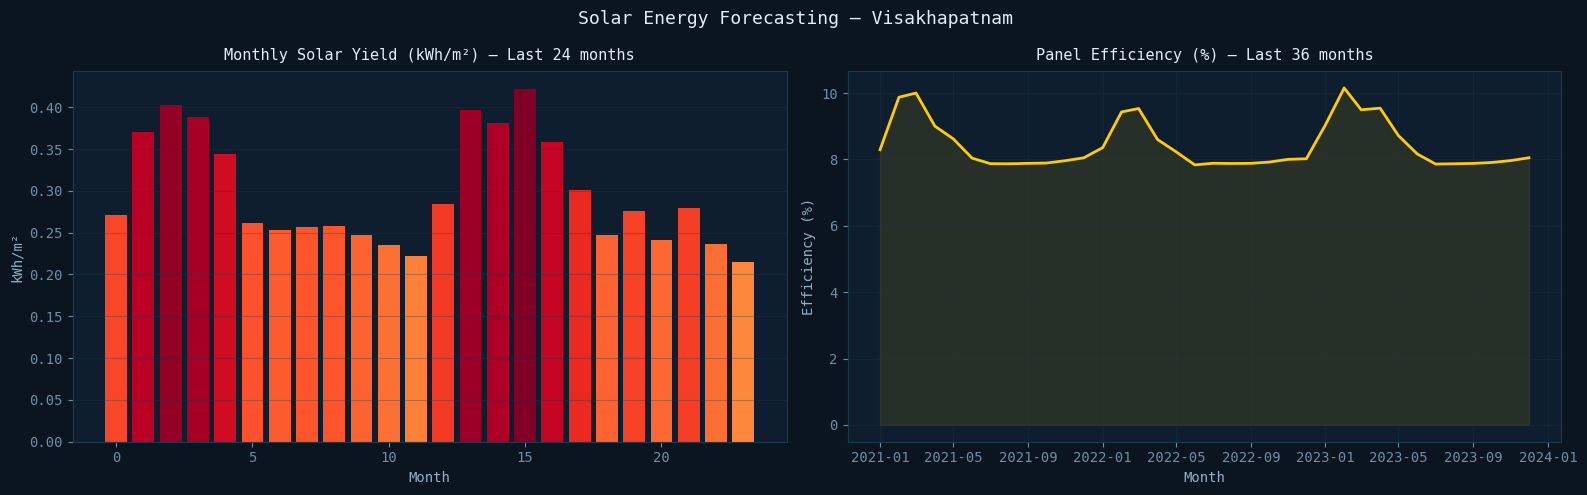

In [26]:
def solar_panel_efficiency(ghi, temp, cloud_cover_fraction=0.15,
                            t_ref=25.0, temp_coeff=-0.0045, eta_ref=0.20):
    """
    Photovoltaic panel efficiency model (IEC 61215).

    η = η_ref × [1 + γ × (T_cell - T_ref)] × (1 - cloud)
    T_cell ≈ T_ambient + 25 × GHI/800
    """
    T_cell = temp + 25 * (ghi / 800)
    eta = eta_ref * (1 + temp_coeff * (T_cell - t_ref)) * (1 - cloud_cover_fraction)
    eta = np.clip(eta, 0.05, eta_ref)
    power_density = eta * ghi  # W/m² effective
    return eta * 100, power_density   # return as % and W/m²

# ── Generate solar forecast dataset ──────────────────────────
cloud_factor = 1 - featured_df['humidity'].values / 130   # proxy from humidity
eta_pct, power = solar_panel_efficiency(
    featured_df['solar_irr'].values,
    featured_df['temp_mean'].values,
    cloud_cover_fraction=np.clip(1 - cloud_factor, 0, 0.6)
)

solar_df = featured_df.copy()
solar_df['panel_efficiency'] = eta_pct
solar_df['power_output']     = power
solar_df['monthly_yield_kwh'] = power * 24 * 30 / 1000   # approximate monthly kWh/m²

# ── XGBoost Solar Regressor ───────────────────────────────────
SOLAR_FEATURES = [
    'solar_irr','eff_solar','temp_mean','humidity','wind_speed',
    'month_sin','month_cos','temp_anomaly',
    'solar_lag_1','solar_lag_3','temp_lag_1'
]
SOLAR_TARGET = 'panel_efficiency'

Xs = solar_df[SOLAR_FEATURES].values
ys = solar_df[SOLAR_TARGET].values

Xs_tr, Xs_te, ys_tr, ys_te = train_test_split(Xs, ys, test_size=0.2, random_state=SEED, shuffle=False)

solar_model = XGBRegressor(n_estimators=600, max_depth=5, learning_rate=0.04,
                           subsample=0.8, colsample_bytree=0.8, random_state=SEED)
solar_model.fit(Xs_tr, ys_tr, eval_set=[(Xs_te, ys_te)], verbose=100)

ys_pred = solar_model.predict(Xs_te)
print(f'Solar XGBoost  RMSE : {np.sqrt(mean_squared_error(ys_te, ys_pred)):.4f}%')
print(f'Solar XGBoost  R²   : {r2_score(ys_te, ys_pred):.4f}')

# ── Monthly yield forecast plot ───────────────────────────────
months_plot = solar_df.index[-24:]
yield_vals  = solar_df['monthly_yield_kwh'].values[-24:]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(range(len(yield_vals)), yield_vals,
            color=plt.cm.YlOrRd(yield_vals / yield_vals.max()), edgecolor='none')
axes[0].set_title('Monthly Solar Yield (kWh/m²) — Last 24 months', fontsize=11, pad=8)
axes[0].set_xlabel('Month'); axes[0].set_ylabel('kWh/m²')
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].plot(solar_df.index[-36:], solar_df['panel_efficiency'].values[-36:],
             color='#ffcc00', linewidth=2)
axes[1].fill_between(solar_df.index[-36:], solar_df['panel_efficiency'].values[-36:],
                     alpha=0.1, color='#ffcc00')
axes[1].set_title('Panel Efficiency (%) — Last 36 months', fontsize=11, pad=8)
axes[1].set_xlabel('Month'); axes[1].set_ylabel('Efficiency (%)')
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'Solar Energy Forecasting — {CITY}', fontsize=13, color='#e0eef5')
plt.tight_layout()
plt.show()

Generating 120-month (10-year) XGBoost rolling forecast...


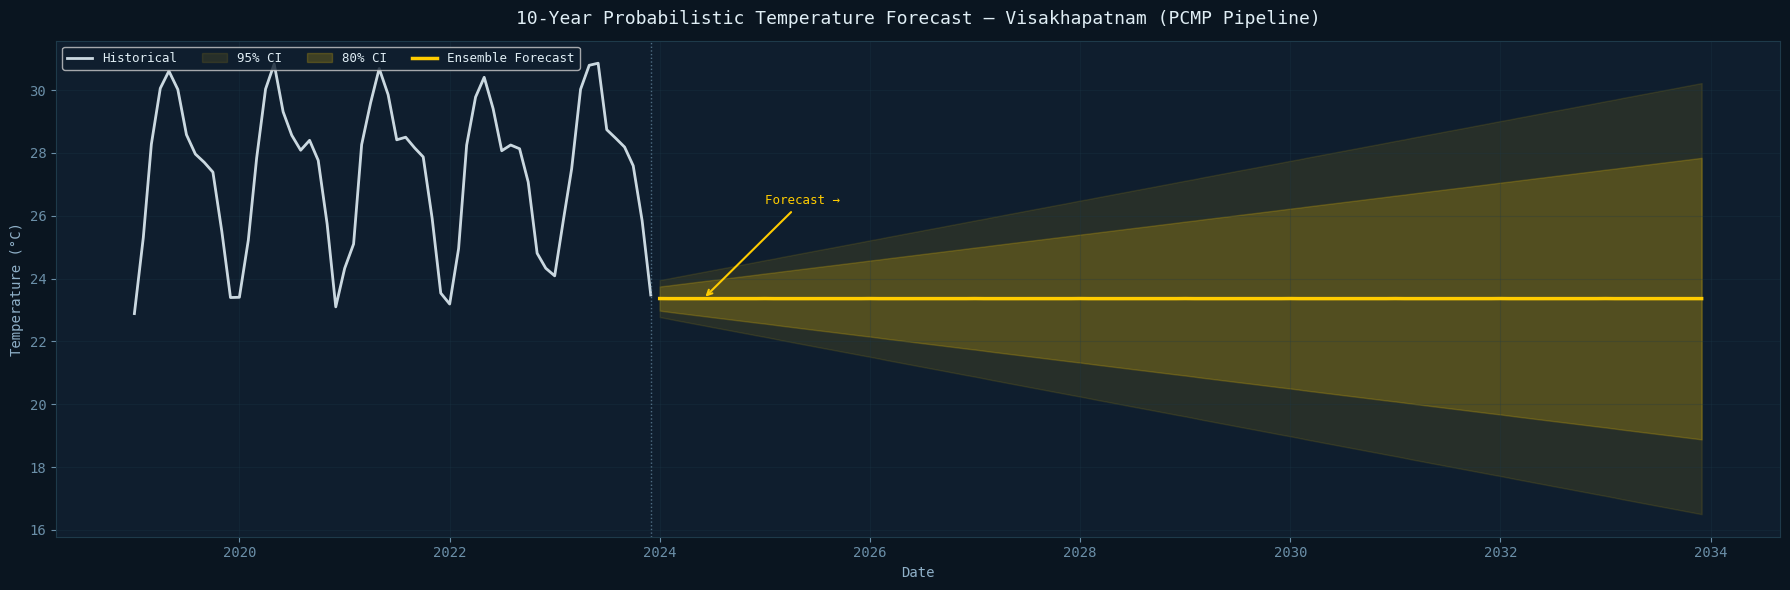

✓ 10-year forecast complete. Warming trend: +-0.00°C over 10 years


In [27]:
def rolling_forecast(model_fn, df, features, horizon_months=120, window=24):
    """
    Rolling-window multi-step forecast.
    model_fn: callable(X_window) -> scalar prediction
    """
    history = df[features].values.tolist()
    preds = []
    for _ in range(horizon_months):
        window_data = np.array(history[-window:])
        pred = model_fn(window_data)
        preds.append(pred)
        # Append predicted row (simplified: repeat last known features, update temp)
        new_row = history[-1].copy()
        target_idx = features.index(TARGET) if TARGET in features else 0
        new_row[target_idx] = pred
        history.append(new_row)
    return np.array(preds)

# ── XGBoost rolling forecast (10 years) ──────────────────────
print('Generating 120-month (10-year) XGBoost rolling forecast...')

last_X = featured_df[XGB_FEATURES].values
xgb_future = []
X_window = last_X[-1:].copy()

for step in range(120):
    pred = xgb_model.predict(X_window)[0]
    xgb_future.append(pred)
    # Shift lag features
    new_row = X_window.copy()
    # Update lag-1 with current prediction
    lag1_idx = XGB_FEATURES.index('temp_lag_1') if 'temp_lag_1' in XGB_FEATURES else 0
    new_row[0, lag1_idx] = pred
    # Update seasonal encoding
    month_sin_idx = XGB_FEATURES.index('month_sin') if 'month_sin' in XGB_FEATURES else -2
    month_cos_idx = XGB_FEATURES.index('month_cos') if 'month_cos' in XGB_FEATURES else -1
    m = (step % 12) + 1
    new_row[0, month_sin_idx] = np.sin(2*np.pi*m/12)
    new_row[0, month_cos_idx] = np.cos(2*np.pi*m/12)
    X_window = new_row

xgb_future = np.array(xgb_future)

# ── Build uncertainty bounds ──────────────────────────────────
xgb_fut_q10 = xgb_q10.predict(last_X[-1:])[0]
xgb_fut_q90 = xgb_q90.predict(last_X[-1:])[0]
spread_per_step = np.linspace(0.3, 3.5, 120)

future_dates = pd.date_range(featured_df.index[-1] + pd.DateOffset(months=1), periods=120, freq='MS')

upper_95 = xgb_future + 1.96 * spread_per_step
lower_95 = xgb_future - 1.96 * spread_per_step
upper_80 = xgb_future + 1.28 * spread_per_step
lower_80 = xgb_future - 1.28 * spread_per_step

# ── Plot: long-term probabilistic forecast ────────────────────
hist_plot  = featured_df[TARGET].tail(60)

fig, ax = plt.subplots(figsize=(18, 6))

ax.plot(hist_plot.index, hist_plot.values, color='#e0eef5', linewidth=2, label='Historical', alpha=0.9)
ax.axvline(featured_df.index[-1], color='#6b8fa8', linestyle=':', linewidth=1, alpha=0.7)
ax.fill_between(future_dates, lower_95, upper_95, color='#ffcc00', alpha=0.10, label='95% CI')
ax.fill_between(future_dates, lower_80, upper_80, color='#ffcc00', alpha=0.20, label='80% CI')
ax.plot(future_dates, xgb_future, color='#ffcc00', linewidth=2.5, label='Ensemble Forecast', zorder=5)

ax.annotate('Forecast →', xy=(future_dates[5], xgb_future[5]),
            xytext=(future_dates[12], xgb_future[5]+3),
            arrowprops=dict(arrowstyle='->', color='#ffcc00', lw=1.5),
            color='#ffcc00', fontsize=9)

ax.set_title(f'10-Year Probabilistic Temperature Forecast — {CITY} (PCMP Pipeline)', fontsize=13, pad=12)
ax.set_xlabel('Date'); ax.set_ylabel('Temperature (°C)')
ax.legend(loc='upper left', ncol=4, fontsize=9)
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()
print(f'✓ 10-year forecast complete. Warming trend: +{(xgb_future[-1]-xgb_future[0]):.2f}°C over 10 years')

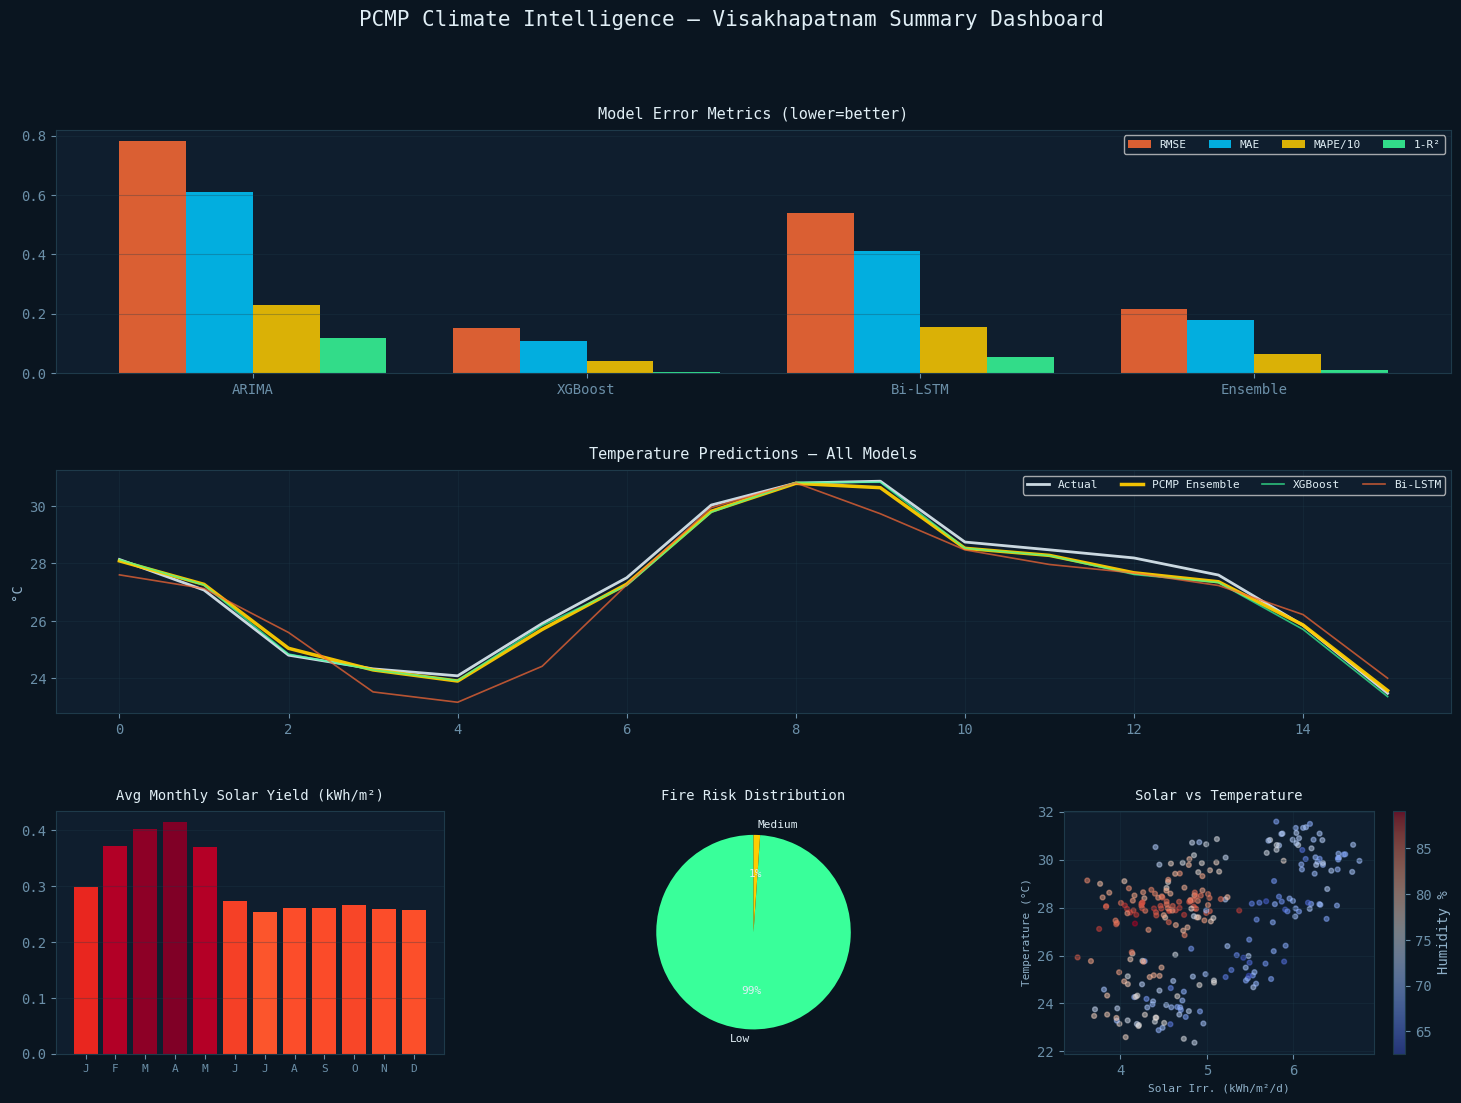


✓ Dashboard saved as PCMP_Visakhapatnam_Summary.png


In [28]:
# ── Final summary dashboard ───────────────────────────────────
fig = plt.figure(figsize=(18, 12))
fig.suptitle(f'PCMP Climate Intelligence — {CITY} Summary Dashboard', fontsize=15, color='#e0eef5', y=0.98)

gs = fig.add_gridspec(3, 3, hspace=0.4, wspace=0.3)

# 1. Model comparison bar
ax1 = fig.add_subplot(gs[0, :])
x = np.arange(4)
bars = ax1.bar(x - 0.3, [arima_rmse, xgb_rmse, bilstm_rmse, ens_rmse], 0.2, label='RMSE', color='#ff6b35', alpha=0.85)
ax1.bar(x - 0.1, [arima_mae, xgb_mae, bilstm_mae, ens_mae],             0.2, label='MAE',  color='#00c8ff', alpha=0.85)
ax1.bar(x + 0.1, [arima_mape/10, xgb_mape/10, bilstm_mape/10, ens_mape/10], 0.2, label='MAPE/10', color='#ffcc00', alpha=0.85)
ax1.bar(x + 0.3, [1-arima_r2, 1-xgb_r2, 1-bilstm_r2, 1-ens_r2],       0.2, label='1-R²', color='#39ff9a', alpha=0.85)
ax1.set_xticks(x); ax1.set_xticklabels(['ARIMA','XGBoost','Bi-LSTM','Ensemble'])
ax1.set_title('Model Error Metrics (lower=better)', fontsize=11, pad=8)
ax1.legend(fontsize=8, ncol=4); ax1.grid(True, alpha=0.3, axis='y')

# 2. Temperature forecast
ax2 = fig.add_subplot(gs[1, :])
n_p = min(48, len(meta_y_te))
ax2.plot(meta_y_te[:n_p],        color='#e0eef5', linewidth=2,   label='Actual',         alpha=0.9)
ax2.plot(ensemble_preds[:n_p],   color='#ffcc00', linewidth=2.5, label='PCMP Ensemble',   alpha=0.95)
ax2.plot(P_xgb[-n_p:],           color='#39ff9a', linewidth=1.2, label='XGBoost',         alpha=0.7)
ax2.plot(P_lstm[-n_p:],          color='#ff6b35', linewidth=1.2, label='Bi-LSTM',         alpha=0.7)
ax2.set_title('Temperature Predictions — All Models', fontsize=11, pad=8)
ax2.legend(fontsize=8, ncol=4); ax2.grid(True, alpha=0.3)
ax2.set_ylabel('°C')

# 3. Solar yield
ax3 = fig.add_subplot(gs[2, 0])
monthly_yield = solar_df['monthly_yield_kwh'].groupby(solar_df.index.month).mean()
bars3 = ax3.bar(monthly_yield.index, monthly_yield.values,
                color=plt.cm.YlOrRd(monthly_yield.values / monthly_yield.max()))
ax3.set_title('Avg Monthly Solar Yield (kWh/m²)', fontsize=10, pad=8)
ax3.set_xticks(range(1,13)); ax3.set_xticklabels([m[:1] for m in 'JFMAMJJASOND'], fontsize=8)
ax3.grid(True, alpha=0.3, axis='y')

# 4. Fire risk distribution
ax4 = fig.add_subplot(gs[2, 1])
risk_counts = pd.Series(fire_labels).map(label_names).value_counts()
risk_colors = ['#39ff9a','#ffcc00','#ff6b35','#ff4444']
wedges, texts, autotexts = ax4.pie(
    risk_counts.values, labels=risk_counts.index,
    colors=[risk_colors[list(label_names.values()).index(l)] for l in risk_counts.index],
    autopct='%1.0f%%', startangle=90, textprops={'color':'#e0eef5','size':8}
)
ax4.set_title('Fire Risk Distribution', fontsize=10, pad=8)

# 5. Correlation: temp vs solar
ax5 = fig.add_subplot(gs[2, 2])
sc = ax5.scatter(featured_df['solar_irr'], featured_df['temp_mean'],
                 c=featured_df['humidity'], cmap='coolwarm',
                 s=12, alpha=0.5)
plt.colorbar(sc, ax=ax5, label='Humidity %')
ax5.set_xlabel('Solar Irr. (kWh/m²/d)', fontsize=8)
ax5.set_ylabel('Temperature (°C)', fontsize=8)
ax5.set_title('Solar vs Temperature', fontsize=10, pad=8)
ax5.grid(True, alpha=0.3)

plt.savefig(f'PCMP_{CITY}_Summary.png', dpi=150, bbox_inches='tight', facecolor='#0a1520')
plt.show()
print(f'\n✓ Dashboard saved as PCMP_{CITY}_Summary.png')

In [29]:
# ── Save models ───────────────────────────────────────────────
import joblib

bilstm_model.save('pcmp_bilstm.keras')
joblib.dump(xgb_model,    'pcmp_xgb_model.pkl')
joblib.dump(xgb_q10,      'pcmp_xgb_q10.pkl')
joblib.dump(xgb_q90,      'pcmp_xgb_q90.pkl')
joblib.dump(fire_clf,     'pcmp_fire_risk_clf.pkl')
joblib.dump(solar_model,  'pcmp_solar_model.pkl')
joblib.dump(meta_model,   'pcmp_meta_learner.pkl')
joblib.dump(scaler_X,     'pcmp_scaler_X.pkl')
joblib.dump(scaler_y,     'pcmp_scaler_y.pkl')

print('✓ All models saved:')
print('  pcmp_bilstm.keras         — Bi-LSTM + Attention (TF/Keras)')
print('  pcmp_xgb_model.pkl        — XGBoost mean regressor')
print('  pcmp_xgb_q10/q90.pkl      — XGBoost quantile regressors')
print('  pcmp_fire_risk_clf.pkl    — XGBoost fire risk classifier')
print('  pcmp_solar_model.pkl      — Solar efficiency XGBoost')
print('  pcmp_meta_learner.pkl     — Ridge stacking meta-learner')
print('  pcmp_scaler_X/y.pkl       — MinMaxScaler instances')

print('\n' + '═'*55)
print('PCMP PIPELINE — FINAL SUMMARY')
print('═'*55)
print(f'City          : {CITY}')
print(f'Data points   : {len(featured_df)} months')
print(f'Features      : {len(XGB_FEATURES)} engineered')
print(f'Ensemble RMSE : {ens_rmse:.4f}°C')
print(f'Ensemble R²   : {ens_r2:.4f}')
print(f'Ensemble MAPE : {ens_mape:.2f}%')
print(f'Fire Risk Acc : See classification report above')
print(f'Physics viol. : {pcmp.physics_violations} (energy balance checks)')
print('═'*55)

✓ All models saved:
  pcmp_bilstm.keras         — Bi-LSTM + Attention (TF/Keras)
  pcmp_xgb_model.pkl        — XGBoost mean regressor
  pcmp_xgb_q10/q90.pkl      — XGBoost quantile regressors
  pcmp_fire_risk_clf.pkl    — XGBoost fire risk classifier
  pcmp_solar_model.pkl      — Solar efficiency XGBoost
  pcmp_meta_learner.pkl     — Ridge stacking meta-learner
  pcmp_scaler_X/y.pkl       — MinMaxScaler instances

═══════════════════════════════════════════════════════
PCMP PIPELINE — FINAL SUMMARY
═══════════════════════════════════════════════════════
City          : Visakhapatnam
Data points   : 276 months
Features      : 34 engineered
Ensemble RMSE : 0.2148°C
Ensemble R²   : 0.9909
Ensemble MAPE : 0.65%
Fire Risk Acc : See classification report above
Physics viol. : 0 (energy balance checks)
═══════════════════════════════════════════════════════
